# Module 4.4 — Forecast Anomaly Detection Engine
## Digital Finance, Forecasting & Analytics Platform

**Purpose:** Multi-layer anomaly detection on IFRS *projection* data (forecast scenario).
Validates forecast plausibility, consistency and accuracy — connecting directly to the PostgreSQL DW.

**Data sources (forecast):** `vw_pl_monthly_forecast` · `vw_cf_monthly_forecast` · `vw_bs_monthly_forecast`
**Reference (actuals):** `vw_pl_monthly` · `vw_cf_monthly` · `vw_bs_monthly`

| Layer | Name | What it checks |
|-------|------|----------------|
| 1A | Quality gate | Nulls, duplicates, date gaps |
| 2  | Accuracy (overlap) | MAPE, WAPE, Bias for months with actuals |
| 3A | Margin plausibility | Gross margin %, EBITDA margin % vs historical bands |
| 3B | Growth plausibility | YoY growth thresholds per KPI |
| 3C | Seasonality compliance | Forecast vs seasonal pattern from actuals |
| 3D | Junction smoothness | MoM change at actuals → forecast transition |
| 3E | BS balance | Assets = Liabilities + Equity in forecast |
| 4  | Statistical detection | Z-Score + STL + Isolation Forest on forecast series |
| 5  | Ensemble score | Weighted composite → NORMAL / WATCH / WARNING / ALERT |
| —  | **TEST_MODE** | Synthetic anomaly injection in-memory → validates detection |

In [1]:
import os
import logging
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from dotenv import load_dotenv
from sqlalchemy import create_engine, text
from sqlalchemy.exc import SQLAlchemyError

from scipy.stats import zscore
from statsmodels.tsa.seasonal import STL
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s", datefmt="%H:%M:%S")
logger = logging.getLogger(__name__)

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_colwidth", 60)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.0)

# Schema =============================================================================
SCHEMA = "finance_ifrs_dw"

# Detection thresholds ===============================================================
THRESHOLD_Z     = 2.5
STL_PERIOD      = 12
IF_N_EST        = 200 #  Isolation Forest 200 trees
IF_CONTAM       = 0.05 # anomalies in the Isolation Forest

# Plausibility thresholds ============================================================
MARGIN_STD_MULT   = 2.0   # margins outside mean N*std of actuals history flag
YOY_STD_MULT      = 1.0   # revenue YoY outside mean N*std of actuals history  flag
JUNCTION_MOM_MULT = 2.0   # MoM at junction > N * avg historical MoM ? flag

# Ensemble weights ===================================================================
W_ACCURACY     = 0.20   # Layer 2 accuracy on overlap months
W_PLAUSIBILITY = 0.45   # Layers 3A-3E plausibility checks
W_STATISTICAL  = 0.35   # Layer 4 statistical detection

print("Libraries loaded.")
print(f"Schema: {SCHEMA} ")
print(f"Ensemble weights ? Accuracy {W_ACCURACY:.0%} | Plausibility {W_PLAUSIBILITY:.0%} | Statistical {W_STATISTICAL:.0%}")


Libraries loaded.
Schema: finance_ifrs_dw 
Ensemble weights ? Accuracy 20% | Plausibility 45% | Statistical 35%


In [2]:
load_dotenv()

DB_USER = os.getenv("DB_USER")
DB_PASS = os.getenv("DB_PASS")
DB_HOST = os.getenv("DB_HOST", "localhost")
DB_PORT = os.getenv("DB_PORT", "5432")
DB_NAME = os.getenv("DB_NAME")

if not all([DB_USER, DB_PASS, DB_NAME]):
    raise EnvironmentError("Missing DB credentials in .env (DB_USER, DB_PASS, DB_NAME required).")

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}",
    pool_pre_ping=True
)

with engine.connect() as conn:
    result = conn.execute(text("SELECT current_database(), current_schema()"))
    db, schema = result.fetchone()
    print(f"Connected: {db} | schema: {schema}")

logger.info("DB connection established.")

17:28:26 [INFO] DB connection established.


Connected: finance_ifrs_dw | schema: public


### Forecast and Actual Views Extraction


In [3]:
def _parse_datekey(df: pd.DataFrame) -> pd.DataFrame:
    """Normalize datekey to Int64 YYYYMM + add date column (consistent with Module 3.2)."""
    if "datekey" in df.columns:
        df["datekey"] = pd.to_numeric(df["datekey"], errors="coerce").astype("Int64")
        df["date"] = pd.to_datetime(df["datekey"].astype(str), format="%Y%m", errors="coerce")
    return df


def _load_view(view_name: str) -> pd.DataFrame:
    try:
        df = pd.read_sql(f"SELECT * FROM {SCHEMA}.{view_name} ORDER BY datekey", engine).round(2)
        return _parse_datekey(df)
    except SQLAlchemyError as e:
        logger.error(f"Failed to load {view_name}: {e}")
        return pd.DataFrame()


# ── Forecast views ────────────────────────────────────────────────────────────
print("Extracting forecast views...")
df_plf = _load_view("vw_pl_monthly_forecast")
df_cff = _load_view("vw_cf_monthly_forecast")
df_bsf = _load_view("vw_bs_monthly_forecast")

# ── Actuals views (reference) ─────────────────────────────────────────────────
print("Extracting actuals views (reference)...")
df_plm = _load_view("vw_pl_monthly")
df_cfm = _load_view("vw_cf_monthly")
df_bsm = _load_view("vw_bs_monthly")

for name, df in [
    ("vw_pl_monthly_forecast", df_plf),
    ("vw_cf_monthly_forecast", df_cff),
    ("vw_bs_monthly_forecast", df_bsf),
    ("vw_pl_monthly",          df_plm),
    ("vw_cf_monthly",          df_cfm),
    ("vw_bs_monthly",          df_bsm),
]:
    if not df.empty and "date" in df.columns:
        rng = f"{df['date'].min().strftime('%Y-%m')} -> {df['date'].max().strftime('%Y-%m')}"
        print(f"  {name:32s}: {df.shape[0]:4d} rows x {df.shape[1]:2d} cols | {rng}")
    else:
        print(f"  {name:32s}: {'EMPTY' if df.empty else 'loaded (no date col)'}")

# ── Column name lookups (lowercase) ──────────────────────────────────────────
plf_lower = {c.lower(): c for c in df_plf.columns}
plm_lower = {c.lower(): c for c in df_plm.columns}
bsf_lower = {c.lower(): c for c in df_bsf.columns}
bsm_lower = {c.lower(): c for c in df_bsm.columns}
cff_lower = {c.lower(): c for c in df_cff.columns}

# ── Overlap detection ─────────────────────────────────────────────────────────
actual_datekeys    = set(df_plm["datekey"].dropna()) if not df_plm.empty else set()
forecast_datekeys  = set(df_plf["datekey"].dropna()) if not df_plf.empty else set()
overlap_datekeys   = actual_datekeys & forecast_datekeys
fcast_only_datekeys = forecast_datekeys - actual_datekeys

print(f"\nActuals periods      : {len(actual_datekeys)}")
print(f"Forecast periods     : {len(forecast_datekeys)}")
print(f"Overlap (both exist) : {len(overlap_datekeys)}")
print(f"Forecast-only future : {len(fcast_only_datekeys)}")

Extracting forecast views...
Extracting actuals views (reference)...
  vw_pl_monthly_forecast          :   24 rows x 17 cols | 2023-01 -> 2024-12
  vw_cf_monthly_forecast          :   24 rows x 13 cols | 2023-01 -> 2024-12
  vw_bs_monthly_forecast          :   24 rows x 24 cols | 2023-01 -> 2024-12
  vw_pl_monthly                   :  180 rows x 19 cols | 2010-01 -> 2024-12
  vw_cf_monthly                   :  180 rows x 13 cols | 2010-01 -> 2024-12
  vw_bs_monthly                   :  180 rows x 24 cols | 2010-01 -> 2024-12

Actuals periods      : 180
Forecast periods     : 24
Overlap (both exist) : 24
Forecast-only future : 0


### Scenario Fact Tables Extraction


In [4]:
FACT_TABLES = [
    "fact_sales",
    "fact_cogs",
    "fact_opex",
    "fact_depreciation",
    "fact_assets",
    "fact_debt",
    "fact_equity",
    "fact_taxes",
    "fact_workingcapital",
    "fact_cashflow",
    "fact_price_volume"
]

SCENARIO_KEY = 3

def extract_fact(fact_name: str) -> pd.DataFrame:
    query = f"""
        SELECT d.MonthYear, f.*
        FROM {SCHEMA}.{fact_name} f
        JOIN {SCHEMA}.dim_date d ON f.DateKey = d.DateKey
        WHERE f.scenariokey = {SCENARIO_KEY}
        ORDER BY d.MonthYear
    """
    df = pd.read_sql(query, engine).round(2)
    for col in ["datekey", "DateKey"]:
        if col in df.columns:
            df.rename(columns={col: "datekey"}, inplace=True)
            df["datekey"] = pd.to_numeric(df["datekey"], errors="coerce").astype("Int64")
            df["date"] = pd.to_datetime(df["datekey"].astype(str), format="%Y%m", errors="coerce")
            break
    return df

facts = {}
print(f"Extracting fact tables (scenariokey={SCENARIO_KEY})...")
for name in FACT_TABLES:
    try:
        facts[name] = extract_fact(name)
        df = facts[name]
        if not df.empty and "date" in df.columns and df["date"].notna().any():
            rng = f"{df['date'].min().strftime('%Y-%m')} -> {df['date'].max().strftime('%Y-%m')}"
            print(f"  {name:32s}: {df.shape[0]:4d} rows x {df.shape[1]:2d} cols | {rng}")
        else:
            print(f"  {name:32s}: {'EMPTY' if df.empty else 'loaded (no date col)'}")
    except SQLAlchemyError as e:
        logger.error(f"Failed to load {name}: {e}")
        facts[name] = pd.DataFrame()
        print(f"  {name:32s}: EMPTY")

fact_period_sets = {
    name: set(df["datekey"].dropna())
    for name, df in facts.items()
    if not df.empty and "datekey" in df.columns
}
forecast_fact_datekeys = set.intersection(*fact_period_sets.values()) if fact_period_sets else set()
actual_fact_datekeys = actual_datekeys if "actual_datekeys" in globals() else set()
overlap_fact_datekeys = actual_fact_datekeys & forecast_fact_datekeys
fcast_only_fact_datekeys = forecast_fact_datekeys - actual_fact_datekeys

print(f"\nActuals periods      : {len(actual_fact_datekeys)}")
print(f"Forecast periods     : {len(forecast_fact_datekeys)}")
print(f"Overlap (both exist) : {len(overlap_fact_datekeys)}")
print(f"Forecast-only future : {len(fcast_only_fact_datekeys)}")


Extracting fact tables (scenariokey=3)...
  fact_sales                      :  216 rows x  9 cols | 2023-01 -> 2024-12
  fact_cogs                       :   72 rows x  8 cols | 2023-01 -> 2024-12
  fact_opex                       :  168 rows x  8 cols | 2023-01 -> 2024-12
  fact_depreciation               :   24 rows x  7 cols | 2023-01 -> 2024-12
  fact_assets                     :  144 rows x  7 cols | 2023-01 -> 2024-12
  fact_debt                       :   96 rows x  7 cols | 2023-01 -> 2024-12
  fact_equity                     :   72 rows x  7 cols | 2023-01 -> 2024-12
  fact_taxes                      :   48 rows x  7 cols | 2023-01 -> 2024-12
  fact_workingcapital             :   72 rows x  7 cols | 2023-01 -> 2024-12
  fact_cashflow                   :  216 rows x  7 cols | 2023-01 -> 2024-12
  fact_price_volume               :  216 rows x  8 cols | 2023-01 -> 2024-12

Actuals periods      : 180
Forecast periods     : 24
Overlap (both exist) : 24
Forecast-only future : 0


### Layer 1A - Forecast Data Quality Gate

This layer validates the basic quality of the forecast datasets before anomaly detection.  
It checks whether data was loaded, numeric fields have nulls, date keys are duplicated, and monthly periods are missing.

In [5]:
quality_results = []

def _add_quality(check, passed, detail, score=None):
    quality_results.append({
        "check": check,
        "status": "PASS" if passed else "FAIL",
        "detail": detail,
        "score": 0 if passed else (score or 100)
    })


def _check_view_quality(df: pd.DataFrame, name: str):
    if df.empty:
        _add_quality(f"{name}: loaded", False, "DataFrame is EMPTY", 100)
        return
    _add_quality(f"{name}: loaded", True, f"{df.shape[0]} rows x {df.shape[1]} cols")

    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    null_total = int(df[num_cols].isnull().sum().sum())
    null_pct   = df[num_cols].isnull().mean().mean() * 100 if num_cols else 0.0
    _add_quality(f"{name}: nulls", null_total == 0,
                 f"Null count in numeric cols: {null_total} ({null_pct:.1f}%)",
                 min(100, null_pct * 5))

    dup_count = int(df["datekey"].duplicated().sum()) if "datekey" in df.columns else 0
    _add_quality(f"{name}: duplicates", dup_count == 0,
                 f"Duplicate datekeys: {dup_count}", min(100, dup_count * 25))

    date_gaps = 0
    if "date" in df.columns:
        ds = df["date"].dropna().sort_values().drop_duplicates()
        if len(ds) > 1:
            expected = pd.date_range(ds.iloc[0], ds.iloc[-1], freq="MS")
            date_gaps = len(expected.difference(pd.DatetimeIndex(ds)))
    _add_quality(f"{name}: date gaps", date_gaps == 0,
                 f"Missing months in series: {date_gaps}", min(100, date_gaps * 20))


for name, df in [
    ("vw_pl_monthly_forecast", df_plf),
    ("vw_cf_monthly_forecast", df_cff),
    ("vw_bs_monthly_forecast", df_bsf),
]:
    _check_view_quality(df, name)

df_quality = pd.DataFrame(quality_results)
pass_count = (df_quality["status"] == "PASS").sum()
fail_count = (df_quality["status"] == "FAIL").sum()

print("=" * 70)
print("LAYER 1A — FORECAST DATA QUALITY GATE")
print("=" * 70)
print(df_quality.to_string(index=False))
print(f"\n{pass_count} PASS | {fail_count} FAIL (of {len(df_quality)} checks)")

LAYER 1A — FORECAST DATA QUALITY GATE
                             check status                               detail  score
    vw_pl_monthly_forecast: loaded   PASS                    24 rows x 17 cols      0
     vw_pl_monthly_forecast: nulls   PASS Null count in numeric cols: 0 (0.0%)      0
vw_pl_monthly_forecast: duplicates   PASS                Duplicate datekeys: 0      0
 vw_pl_monthly_forecast: date gaps   PASS          Missing months in series: 0      0
    vw_cf_monthly_forecast: loaded   PASS                    24 rows x 13 cols      0
     vw_cf_monthly_forecast: nulls   PASS Null count in numeric cols: 0 (0.0%)      0
vw_cf_monthly_forecast: duplicates   PASS                Duplicate datekeys: 0      0
 vw_cf_monthly_forecast: date gaps   PASS          Missing months in series: 0      0
    vw_bs_monthly_forecast: loaded   PASS                    24 rows x 24 cols      0
     vw_bs_monthly_forecast: nulls   PASS Null count in numeric cols: 0 (0.0%)      0
vw_bs_monthly_fo

### Layer 2 - Forecast Accuracy on Overlap Months

This layer evaluates forecast accuracy only for months where both actual and forecast values are available.  
For each KPI, it compares forecast vs actual values and reports MAE, RMSE, MAPE, WAPE, and Bias.

The status is based on MAPE:
- **PASS**: MAPE below 10%, indicating good forecast accuracy.
- **WATCH**: MAPE between 10% and 20%, indicating moderate deviation that should be monitored.
- **FAIL**: MAPE above 20%, indicating weak forecast accuracy or material forecast error.

In [6]:
# =============================================================================
# Layer 2 — Forecast Accuracy on Overlap Months
# Only runs for months where BOTH actuals and forecast exist.
# Metrics: MAE, RMSE, MAPE, WAPE, Bias per KPI.
# =============================================================================
accuracy_results = []
accuracy_detail_frames = []


def _compute_accuracy(df_f, df_a, col_f, col_a, label, overlap_keys):
    if not overlap_keys:
        return pd.DataFrame()

    df_f2 = df_f[df_f["datekey"].isin(overlap_keys)][["datekey", col_f]].copy()
    df_a2 = df_a[df_a["datekey"].isin(overlap_keys)][["datekey", col_a]].copy()

    merged = pd.merge(
        df_f2.rename(columns={col_f: "forecast"}),
        df_a2.rename(columns={col_a: "actual"}),
        on="datekey",
        how="inner"
    )

    if merged.empty:
        return pd.DataFrame()

    # Erros básicos
    merged["residual"] = merged["actual"] - merged["forecast"]
    merged["abs_error"] = merged["residual"].abs()

    # APE/MAPE corrigido:
    # usa abs(actual) no denominador para evitar APE negativo
    merged["ape"] = (
        merged["abs_error"] /
        merged["actual"].abs().replace(0, np.nan)
    ) * 100

    # Score mensal de erro
    merged["error_score"] = np.clip(
        merged["ape"].fillna(0) / 30 * 100,
        0,
        100
    ).round(2)

    merged["kpi"] = label

    # Métricas agregadas
    mae = merged["abs_error"].mean()
    rmse = np.sqrt((merged["residual"] ** 2).mean())
    mape = merged["ape"].mean()
    wape = merged["abs_error"].sum() / merged["actual"].abs().sum() * 100
    bias_pct = merged["residual"].sum() / merged["actual"].abs().sum() * 100

    accuracy_results.append({
        "kpi": label,
        "n_months": len(merged),
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "MAPE_%": round(mape, 2) if pd.notna(mape) else np.nan,
        "WAPE_%": round(wape, 2) if pd.notna(wape) else np.nan,
        "Bias_%": round(bias_pct, 2) if pd.notna(bias_pct) else np.nan,
        "status": "PASS" if mape < 10 else ("WATCH" if mape < 20 else "FAIL")
    })

    return merged[[
        "datekey", "kpi", "forecast", "actual",
        "residual", "ape", "error_score"
    ]]


# Compare common P&L KPIs
for kpi in ["revenue", "cogs", "gross_profit", "opex", "ebitda", "net_income"]:
    if kpi in plf_lower and kpi in plm_lower:
        frame = _compute_accuracy(
            df_plf,
            df_plm,
            plf_lower[kpi],
            plm_lower[kpi],
            kpi,
            overlap_datekeys
        )
        if not frame.empty:
            accuracy_detail_frames.append(frame)

df_accuracy_detail = (
    pd.concat(accuracy_detail_frames, ignore_index=True)
    if accuracy_detail_frames else pd.DataFrame()
)

# Per-month score: worst APE across KPIs
if not df_accuracy_detail.empty:
    df_accuracy_monthly = (
        df_accuracy_detail.groupby("datekey")["error_score"]
        .max()
        .reset_index()
        .rename(columns={"error_score": "accuracy_score"})
    )
else:
    df_accuracy_monthly = pd.DataFrame(columns=["datekey", "accuracy_score"])

df_cv_accuracy = pd.DataFrame(accuracy_results)

print("=" * 80)
print("LAYER 2 — FORECAST ACCURACY (OVERLAP MONTHS ONLY)")
print("=" * 80)

if not df_cv_accuracy.empty:
    print(df_cv_accuracy.to_string(index=False))
else:
    print("No overlap months found — Layer 2 skipped (all forecast months are future).")

LAYER 2 — FORECAST ACCURACY (OVERLAP MONTHS ONLY)
         kpi  n_months    MAE   RMSE   MAPE_%  WAPE_%  Bias_% status
     revenue        24 299.48 353.96    12.06   11.44    1.29  WATCH
        cogs        24 157.81 185.30    12.37   11.74    1.43  WATCH
gross_profit        24 142.40 172.70    11.79   11.18    1.14  WATCH
        opex        24 100.76 123.22    17.26   17.09   -4.96  WATCH
      ebitda        24 165.02 213.19    32.28   24.10    6.39   FAIL
  net_income        24 157.41 208.62 1,030.57   41.30    8.11   FAIL


### Layer 3A - Margin Plausibility

This layer checks whether forecast margins are consistent with historical actual margins.  
It calculates historical bands for revenue, gross margin and EBITDA margin using the mean and standard deviation of actuals, then compares forecast margins against those ranges.

Forecast months outside the historical margin band may indicate unrealistic profitability assumptions, pricing issues, cost issues, or data inconsistencies.

In [7]:
# =============================================================================
# Layer 3A ? Margin Plausibility
# Historical gross/EBITDA margins from actuals ? mean ? MARGIN_STD_MULT*std band
# Flag forecast months outside the band.
# =============================================================================

def _add_margins(df, lower):
    df = df.copy()
    rev = lower.get("revenue")
    gp  = lower.get("gross_profit")
    eb  = lower.get("ebitda")
    if rev and gp and rev in df.columns and gp in df.columns:
        df["gross_margin_pct"] = (df[gp] / df[rev].replace(0, np.nan) * 100).round(4)
    if rev and eb and rev in df.columns and eb in df.columns:
        df["ebitda_margin_pct"] = (df[eb] / df[rev].replace(0, np.nan) * 100).round(4)
    return df


def _build_hist_band(series: pd.Series, std_mult: float):
    hist = series.dropna()
    if len(hist) < 2:
        return None
    mu, sd = hist.mean(), hist.std()
    return {
        "mean": mu,
        "std": sd,
        "lo": mu - std_mult * sd,
        "hi": mu + std_mult * sd,
    }


def _build_yoy_series(df: pd.DataFrame, value_col: str, new_col: str = "yoy_pct") -> pd.DataFrame:
    out = df[["datekey", value_col]].copy().sort_values("datekey")
    value_map = out.set_index("datekey")[value_col].to_dict()
    yoy_vals = []
    for dk, val in out[["datekey", value_col]].itertuples(index=False):
        dk_int = int(dk)
        yr, mo = dk_int // 100, dk_int % 100
        dk_12 = (yr - 1) * 100 + mo
        prev = value_map.get(dk_12)
        if prev is not None and pd.notna(prev) and prev != 0 and pd.notna(val):
            yoy_vals.append(((val - prev) / abs(prev)) * 100)
        else:
            yoy_vals.append(np.nan)
    out[new_col] = yoy_vals
    return out


df_plm_mg = _add_margins(df_plm, plm_lower)
df_plf_mg = _add_margins(df_plf, plf_lower)

# Compute historical bands from actuals
margin_bands = {}
for m in ["gross_margin_pct", "ebitda_margin_pct"]:
    if m in df_plm_mg.columns:
        band = _build_hist_band(df_plm_mg[m], MARGIN_STD_MULT)
        if band:
            margin_bands[m] = band

rev_a = plm_lower.get("revenue")
rev_f = plf_lower.get("revenue")
revenue_yoy_band = None
if rev_a and rev_a in df_plm.columns:
    df_rev_yoy_actuals = _build_yoy_series(df_plm, rev_a, "revenue_yoy_pct")
    revenue_yoy_band = _build_hist_band(df_rev_yoy_actuals["revenue_yoy_pct"], YOY_STD_MULT)
else:
    df_rev_yoy_actuals = pd.DataFrame()


def _margin_score(row, bands):
    worst = 0.0
    for m, b in bands.items():
        if m in row.index and pd.notna(row[m]) and b["std"] > 0:
            if row[m] < b["lo"]:
                dev = (b["lo"] - row[m]) / b["std"]
            elif row[m] > b["hi"]:
                dev = (row[m] - b["hi"]) / b["std"]
            else:
                dev = 0.0
            worst = max(worst, float(np.clip(dev / MARGIN_STD_MULT * 100, 0, 100)))
    return round(worst, 2)


def _yoy_growth_score(df_f, df_a, col_f, col_a, band):
    """Return a DataFrame with forecast YoY% and score using historical actuals band."""
    combined = pd.concat([
        df_a[["datekey", col_a]].rename(columns={col_a: "val"}),
        df_f[["datekey", col_f]].rename(columns={col_f: "val"}),
    ]).drop_duplicates("datekey").sort_values("datekey")
    val_map = combined.set_index("datekey")["val"].to_dict()

    rows = []
    for dk in df_f["datekey"].dropna():
        dk_int = int(dk)
        yr, mo = dk_int // 100, dk_int % 100
        dk_12 = (yr - 1) * 100 + mo
        yoy_pct = np.nan
        score = 0.0
        if dk_12 in val_map and dk in val_map:
            v_now, v_ago = val_map[dk], val_map[dk_12]
            if v_ago != 0 and pd.notna(v_now) and pd.notna(v_ago):
                yoy_pct = ((v_now - v_ago) / abs(v_ago)) * 100
                if band and band["std"] > 0:
                    if yoy_pct < band["lo"]:
                        dev = (band["lo"] - yoy_pct) / band["std"]
                    elif yoy_pct > band["hi"]:
                        dev = (yoy_pct - band["hi"]) / band["std"]
                    else:
                        dev = 0.0
                    score = float(np.clip(dev / YOY_STD_MULT * 100, 0, 100))
        rows.append({"datekey": dk, "revenue_yoy_pct": yoy_pct, "growth_score": round(score, 2)})
    return pd.DataFrame(rows)


df_plf_mg["margin_score"] = df_plf_mg.apply(_margin_score, axis=1, bands=margin_bands)

print("=" * 70)
print("LAYER 3A: MARGIN PLAUSIBILITY")
print("=" * 70)
for m, b in margin_bands.items():
    print(f"  {m}: historical mean={b['mean']:.1f}% std={b['std']:.1f}%  band [{b['lo']:.1f}%, {b['hi']:.1f}%]")
if revenue_yoy_band:
    print(f"  revenue_yoy_pct: historical mean={revenue_yoy_band['mean']:.1f}% std={revenue_yoy_band['std']:.1f}%  band [{revenue_yoy_band['lo']:.1f}%, {revenue_yoy_band['hi']:.1f}%]")
flagged_m = df_plf_mg[df_plf_mg["margin_score"] > 25]
print(f"  Forecast months outside margin band: {len(flagged_m)}")
if not flagged_m.empty:
    cols = ["datekey"] + [m for m in margin_bands if m in df_plf_mg.columns] + ["margin_score"]
    print(flagged_m[cols].to_string(index=False))

# =============================================================================
# Layer 3B ? YoY Growth Plausibility
# Compare each forecast month to same month 12 months prior (actuals or forecast).
# Threshold band is learned from historical actuals YoY revenue.
# =============================================================================

if rev_f and rev_a and revenue_yoy_band:
    df_growth = _yoy_growth_score(df_plf, df_plm, rev_f, rev_a, revenue_yoy_band)
    df_plf_mg = df_plf_mg.merge(df_growth, on="datekey", how="left")
    df_plf_mg["growth_score"] = df_plf_mg["growth_score"].fillna(0)
else:
    df_plf_mg["revenue_yoy_pct"] = np.nan
    df_plf_mg["growth_score"] = 0.0

print(f"\n{'='*70}")
print("LAYER 3B: YOY GROWTH PLAUSIBILITY")
print(f"{'='*70}")
if revenue_yoy_band:
    print(f"  Historical revenue YoY band: mean={revenue_yoy_band['mean']:.1f}% std={revenue_yoy_band['std']:.1f}%  band [{revenue_yoy_band['lo']:.1f}%, {revenue_yoy_band['hi']:.1f}%]")
else:
    print("  Historical revenue YoY band: unavailable (insufficient history)")
flagged_g = df_plf_mg[df_plf_mg["growth_score"] > 25]
print(f"  Months with implausible YoY growth: {len(flagged_g)}")
if not flagged_g.empty:
    revenue_lookup = pd.concat([
        df_plm[["datekey", rev_a]].rename(columns={rev_a: "revenue"}),
        df_plf[["datekey", rev_f]].rename(columns={rev_f: "revenue"}),
    ]).drop_duplicates("datekey").set_index("datekey")["revenue"]

    flagged_g = flagged_g.copy()
    flagged_g["prior_datekey"] = flagged_g["datekey"].apply(
        lambda dk: (int(dk) // 100 - 1) * 100 + (int(dk) % 100)
    )
    flagged_g["revenue_prior_year"] = flagged_g["prior_datekey"].map(revenue_lookup)
    flagged_g["revenue_current"] = flagged_g["datekey"].map(revenue_lookup)

    print(flagged_g[
        [
            "datekey",
            "prior_datekey",
            "revenue_prior_year",
            "revenue_current",
            "revenue_yoy_pct",
            "growth_score"
        ]
    ].to_string(index=False))


LAYER 3A: MARGIN PLAUSIBILITY
  gross_margin_pct: historical mean=48.8% std=0.8%  band [47.1%, 50.4%]
  ebitda_margin_pct: historical mean=20.9% std=9.5%  band [1.8%, 40.0%]
  revenue_yoy_pct: historical mean=7.5% std=24.4%  band [-16.9%, 31.9%]
  Forecast months outside margin band: 0

LAYER 3B: YOY GROWTH PLAUSIBILITY
  Historical revenue YoY band: mean=7.5% std=24.4%  band [-16.9%, 31.9%]
  Months with implausible YoY growth: 4
 datekey  prior_datekey  revenue_prior_year  revenue_current  revenue_yoy_pct  growth_score
  202306         202206            2,405.49         3,502.86            45.62         56.21
  202309         202209            2,444.78         3,595.04            47.05         62.07
  202312         202212            3,526.05         1,771.44           -49.76        100.00
  202412         202312            1,771.44         2,954.51            66.79        100.00


### Layer 3C - Seasonality Compliance

This layer checks whether forecast revenue follows the historical seasonal pattern.

The model uses STL decomposition on actual revenue history to separate the series into trend, seasonality, and residual noise.  
The last trend value is used as the current baseline revenue level, and the average seasonal effect for each calendar month is added to estimate the expected forecast value.

The score measures how far the forecast revenue is from this seasonally expected value:
- **Score 0**: forecast is aligned with the expected seasonal value.
- **Score 25**: forecast is around 12.5% away from the expected value.
- **Score 50**: forecast is around 25% away from the expected value.
- **Score 100**: forecast is 50% or more away from the expected value.

Months with a score above 25 are flagged as materially deviating from the historical seasonal pattern.

LAYER 3C — SEASONALITY COMPLIANCE
  STL fitted on 180 actuals months | period=12
  Last trend value used as base: 2,762
  Months deviating from seasonal pattern (score > 25): 5
 datekey  seasonality_score
  202301              38.05
  202305              33.30
  202307              36.52
  202308              35.49
  202412              45.53


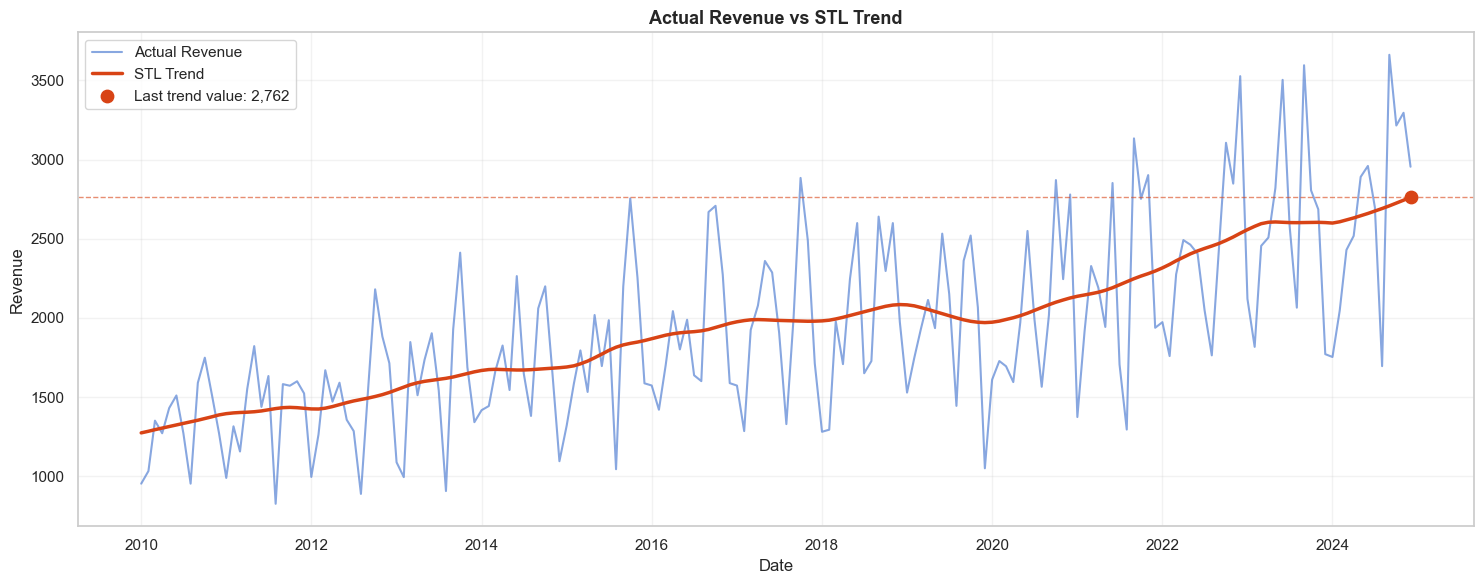

In [8]:
# =============================================================================
# Layer 3C — Seasonality Compliance
# Fit STL on actuals revenue → extract seasonal component per calendar month.
# For each forecast month: expected = trend_last + seasonal_index[month].
# Flag months where forecast deviates significantly from expected.
# =============================================================================
df_plf_mg["seasonality_score"] = 0.0

rev_col_a = plm_lower.get("revenue")
rev_col_f = plf_lower.get("revenue")

if rev_col_a and rev_col_f and not df_plm.empty and len(df_plm) >= STL_PERIOD * 2:
    ts_actual = df_plm.sort_values("datekey")[rev_col_a].fillna(
        df_plm[rev_col_a].median()).values.astype(float)
    try:
        stl_fit = STL(ts_actual, period=STL_PERIOD, robust=True).fit()

        # Average seasonal component per calendar month (1-12)
        df_stl_ref = df_plm[["datekey", "date"]].sort_values("datekey").copy()
        df_stl_ref["seasonal"] = stl_fit.seasonal
        df_stl_ref["month"]    = df_stl_ref["date"].dt.month
        seasonal_index         = df_stl_ref.groupby("month")["seasonal"].mean()
        last_trend             = float(stl_fit.trend[-1])

        df_seas = df_plf[["datekey", "date", rev_col_f]].copy()
        df_seas["month"]            = df_seas["date"].dt.month
        df_seas["seasonal_adj"]     = df_seas["month"].map(seasonal_index)
        df_seas["value_expected"]   = last_trend + df_seas["seasonal_adj"]
        df_seas["seas_dev_pct"]     = (
            (df_seas[rev_col_f] - df_seas["value_expected"]).abs()
            / df_seas["value_expected"].replace(0, np.nan).abs() * 100
        )
        df_seas["seasonality_score"] = np.clip(
            df_seas["seas_dev_pct"].fillna(0) / 50 * 100, 0, 100
        ).round(2)

        df_plf_mg = df_plf_mg.merge(
            df_seas[["datekey", "seasonality_score"]], on="datekey", how="left", suffixes=("_old", "")
        )
        if "seasonality_score_old" in df_plf_mg.columns:
            df_plf_mg.drop(columns=["seasonality_score_old"], inplace=True)
        df_plf_mg["seasonality_score"] = df_plf_mg["seasonality_score"].fillna(0)

        flagged_s = df_plf_mg[df_plf_mg["seasonality_score"] > 25]
        print("=" * 70)
        print("LAYER 3C — SEASONALITY COMPLIANCE")
        print("=" * 70)
        print(f"  STL fitted on {len(ts_actual)} actuals months | period={STL_PERIOD}")
        print(f"  Last trend value used as base: {last_trend:,.0f}")
        print(f"  Months deviating from seasonal pattern (score > 25): {len(flagged_s)}")
        if not flagged_s.empty:
            print(flagged_s[["datekey", "seasonality_score"]].to_string(index=False))
    except Exception as e:
        logger.error(f"STL failed: {e}")
        print(f"Layer 3C: STL failed — {e}")
else:
    print("Layer 3C: insufficient actuals data — seasonality check skipped.")

# =============================================================================
# Plot STL Trend vs Actual Revenue
# =============================================================================

rev_col_a = plm_lower.get("revenue")

if rev_col_a and not df_plm.empty and len(df_plm) >= STL_PERIOD * 2:
    df_trend_plot = df_plm[["datekey", "date", rev_col_a]].copy().sort_values("datekey")
    ts_actual = df_trend_plot[rev_col_a].fillna(df_trend_plot[rev_col_a].median()).astype(float)

    stl_fit_plot = STL(ts_actual, period=STL_PERIOD, robust=True).fit()

    df_trend_plot["revenue_actual"] = ts_actual.values
    df_trend_plot["stl_trend"] = stl_fit_plot.trend

    last_trend_value = df_trend_plot["stl_trend"].iloc[-1]
    last_trend_date = df_trend_plot["date"].iloc[-1]

    plt.figure(figsize=(15, 6))
    plt.plot(df_trend_plot["date"],df_trend_plot["revenue_actual"],label="Actual Revenue", linewidth=1.5,alpha=0.65)
    plt.plot(df_trend_plot["date"], df_trend_plot["stl_trend"],label="STL Trend",linewidth=2.5,color="#D84315")
    plt.scatter(last_trend_date, last_trend_value, color="#D84315", s=80, zorder=5, label=f"Last trend value: {last_trend_value:,.0f}" )
    plt.axhline(last_trend_value, color="#D84315",linestyle="--",linewidth=1,alpha=0.6 )

    plt.title("Actual Revenue vs STL Trend", fontsize=13, fontweight="bold")
    plt.xlabel("Date")
    plt.ylabel("Revenue")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

else:
    print("Trend plot skipped: insufficient actual revenue history.")

### Layer 3D, 3E and Plausibility Composite

This block completes the forecast plausibility checks.  

**Layer 3D** checks whether the transition from actuals to forecast is smooth by comparing the revenue movement at the junction point against the historical month-over-month pattern.

**Layer 3E** checks whether the forecast balance sheet remains balanced using EquityCheck or, when needed, Assets - Liabilities - Equity. Small residual differences are accepted through a configurable tolerance.

**Plausibility Composite** combines the scores from Layers 3A to 3E into one consolidated score using the weighted formula below:

plausibility_score = 0.30 × margin_score + 0.25 × growth_score + 0.20 × seasonality_score + 0.15 × junction_score + 0.10 × bs_score

Months with a plausibility_score above 25 are flagged for further review.

In [9]:
# =============================================================================
# Layer 3D Junction Smoothness (Actuals -> Forecast)
# Checks MoM% change at the transition vs average historical MoM% in actuals.
# =============================================================================
df_plf_mg["junction_score"] = 0.0
avg_mom_pct = 0.0

rev_col_a = plm_lower.get("revenue")
rev_col_f = plf_lower.get("revenue")

if rev_col_a and rev_col_f and not df_plm.empty and not df_plf.empty:
    plm_s = df_plm.sort_values("datekey")
    plf_s = df_plf.sort_values("datekey")

    last_actual_dk    = plm_s["datekey"].max()
    first_forecast_dk = plf_s["datekey"].min()

    v_last  = plm_s.loc[plm_s["datekey"] == last_actual_dk,  rev_col_a].values
    v_first = plf_s.loc[plf_s["datekey"] == first_forecast_dk, rev_col_f].values

    actual_vals = plm_s[rev_col_a].values.astype(float)
    hist_mom    = np.abs(np.diff(actual_vals) / np.where(actual_vals[:-1] != 0, actual_vals[:-1], np.nan))
    avg_mom_pct = float(np.nanmean(hist_mom) * 100)

    junction_score = 0.0
    detail = "Not computed"
    if len(v_last) > 0 and len(v_first) > 0 and float(v_last[0]) != 0:
        jmom_pct = abs((float(v_first[0]) - float(v_last[0])) / float(v_last[0])) * 100
        if avg_mom_pct > 0:
            ratio = jmom_pct / avg_mom_pct
            junction_score = float(np.clip((ratio - JUNCTION_MOM_MULT) / JUNCTION_MOM_MULT * 100, 0, 100))
        detail = (
            f"Last revenue actual {last_actual_dk}: {float(v_last[0]):,.0f}  |  "
            f"First revenue forecast {first_forecast_dk}: {float(v_first[0]):,.0f}  |  "
            f"Junction MoM: {jmom_pct:.1f}% vs avg historical: {avg_mom_pct:.1f}%"
        )
    df_plf_mg.loc[df_plf_mg["datekey"] == first_forecast_dk, "junction_score"] = round(junction_score, 2)

    j_sev = "PASS" if junction_score < 25 else ("WATCH" if junction_score < 50 else "WARNING" if junction_score < 75 else "ALERT")
    print("=" * 70)
    print("LAYER 3D: JUNCTION SMOOTHNESS")
    print("=" * 70)
    print(f"  {detail}")
    print(f"  Junction score: {junction_score:.1f}  -> {j_sev}")

# =============================================================================
# Layer 3E  Balance Sheet Balance in Forecast
# =============================================================================
eq_check_col = next((bsf_lower[c] for c in ["equitycheck","equity_check"] if c in bsf_lower), None)
col_assets   = next((bsf_lower[c] for c in ["totalassets","total_assets"] if c in bsf_lower), None)
col_liab     = next((bsf_lower[c] for c in ["totalliabilities","total_liabilities"] if c in bsf_lower), None)
col_equity   = next((bsf_lower[c] for c in ["totalequity","total_equity"] if c in bsf_lower), None)
BS_TOL = 0.5  # Adjustable tolerance in the same unit used by EquityCheck.

print(f"\n{'='*70}")
print("LAYER 3E: BALANCE SHEET BALANCE IN FORECAST")
print(f"{'='*70}")

df_bs_score = df_bsf[["datekey"]].copy()
df_bs_score["bs_score"] = 0.0

if not df_bsf.empty:
    if eq_check_col:
        ec = df_bsf[eq_check_col].abs()
        max_ec = ec.max()
        df_bs_score["bs_score"] = np.clip(ec / (BS_TOL + 1e-9) * 100, 0, 100).round(2).values
        print(f"  Using pre-computed EquityCheck: {eq_check_col}")
        print(f"  Tolerance applied: {BS_TOL:,.4f}")
        print(f"  Max imbalance: {max_ec:,.4f} | Months > tolerance: {int((ec > BS_TOL).sum())}")
        print(f"  Status: {'PASS' if max_ec <= BS_TOL else 'FAIL'}")
    elif col_assets and col_liab and col_equity:
        diff = (df_bsf[col_assets] - df_bsf[col_liab] - df_bsf[col_equity]).abs()
        max_diff = diff.max()
        df_bs_score["bs_score"] = np.clip(diff / (BS_TOL + 1e-9) * 100, 0, 100).round(2).values
        print(f"  Recomputed Assets - Liabilities - Equity")
        print(f"  Tolerance applied: {BS_TOL:,.4f}")
        print(f"  Max imbalance: {max_diff:,.4f} | Months > tolerance: {int((diff > BS_TOL).sum())}")
        print(f"  Status: {'PASS' if max_diff <= BS_TOL else 'FAIL'}")
    else:
        print(f"  Skipped ? required columns not found. Available: {list(df_bsf.columns)}")
else:
    print("  Skipped ? df_bsf is empty.")

df_plf_mg = df_plf_mg.merge(df_bs_score[["datekey", "bs_score"]], on="datekey", how="left")
df_plf_mg["bs_score"] = df_plf_mg["bs_score"].fillna(0)

# =============================================================================
# Composite plausibility score (3A-3E)
# =============================================================================
for col in ["margin_score","growth_score","seasonality_score","junction_score","bs_score"]:
    if col not in df_plf_mg.columns:
        df_plf_mg[col] = 0.0

df_plf_mg["plausibility_score"] = np.round(
    0.30 * df_plf_mg["margin_score"]      +
    0.25 * df_plf_mg["growth_score"]      +
    0.20 * df_plf_mg["seasonality_score"] +
    0.15 * df_plf_mg["junction_score"]    +
    0.10 * df_plf_mg["bs_score"],
    2
)

flagged_p = df_plf_mg[df_plf_mg["plausibility_score"] > 25]
print(f"\n{'='*70}")
print("LAYER 3: PLAUSIBILITY COMPOSITE (3A+3B+3C+3D+3E)")
print(f"{'='*70}")
print(f"Months with plausibility concerns (score > 25): {len(flagged_p)}")
show_cols = [c for c in ["datekey","margin_score","growth_score","seasonality_score",
                          "junction_score","bs_score","plausibility_score"] if c in df_plf_mg.columns]
if not flagged_p.empty:
    print(flagged_p.sort_values("plausibility_score", ascending=False)[show_cols].to_string(index=False))

LAYER 3D: JUNCTION SMOOTHNESS
  Last revenue actual 202412: 2,955  |  First revenue forecast 202301: 1,864  |  Junction MoM: 36.9% vs avg historical: 24.3%
  Junction score: 0.0  -> PASS

LAYER 3E: BALANCE SHEET BALANCE IN FORECAST
  Using pre-computed EquityCheck: equitycheck
  Tolerance applied: 0.5000
  Max imbalance: 0.1100 | Months > tolerance: 0
  Status: PASS

LAYER 3: PLAUSIBILITY COMPOSITE (3A+3B+3C+3D+3E)
Months with plausibility concerns (score > 25): 2
 datekey  margin_score  growth_score  seasonality_score  junction_score  bs_score  plausibility_score
  202412          0.00        100.00              45.53            0.00      0.00               34.11
  202312          0.00        100.00               4.74            0.00     22.00               28.15


### Layer 4 - Statistical Anomaly Detection

This layer applies independent statistical tests to the forecast series to identify unusual months.

**Z-Score** checks whether a forecast value is unusually far from the average of its own series. It is useful for detecting extreme spikes or drops.

**STL** decomposes the forecast series into trend, seasonality, and residual noise. It flags months where the residual behavior is unusually large after removing trend and seasonality.

**Isolation Forest** is a machine learning anomaly detection method. It looks across multiple forecast KPIs at the same time and flags months that have an unusual overall pattern.

In [10]:
# =============================================================================
# Layer 4 — Statistical Anomaly Detection on Forecast Series
# Z-Score + STL + Isolation Forest applied to the forecast KPI series.
# =============================================================================
stat_kpis = [plf_lower[k] for k in
             ["revenue","cogs","gross_profit","opex","ebitda","net_income"]
             if k in plf_lower]
print(f"Statistical detection KPIs ({len(stat_kpis)}): {stat_kpis}")

df_plf_s = df_plf.sort_values("datekey").copy()

# ── Z-Score ───────────────────────────────────────────────────────────────────
df_zscore_f = df_plf_s[["datekey","date"] + stat_kpis].copy()
z_matrix = df_zscore_f[stat_kpis].apply(
    lambda col: zscore(col.fillna(col.median()), nan_policy="omit"), axis=0
)
z_matrix.columns = [f"z_{c}" for c in stat_kpis]
df_zscore_f = pd.concat([df_zscore_f, z_matrix], axis=1)
df_zscore_f["z_max_abs"] = z_matrix.abs().max(axis=1)
df_zscore_f["z_score"]   = np.round(np.clip(df_zscore_f["z_max_abs"] / THRESHOLD_Z * 50, 0, 100), 2)

# ── STL on forecast revenue ───────────────────────────────────────────────────
df_stl_f = df_plf_s[["datekey","date"]].copy()
df_stl_f["stl_score"] = 0.0

if len(df_plf_s) >= STL_PERIOD * 2:
    rev_col_f = plf_lower.get("revenue")
    if rev_col_f:
        try:
            ts = df_plf_s[rev_col_f].fillna(df_plf_s[rev_col_f].median()).values.astype(float)
            stl_fit_f = STL(ts, period=STL_PERIOD, robust=True).fit()
            resid = stl_fit_f.resid
            std_r = resid.std()
            if std_r > 0:
                z_r = (resid - resid.mean()) / std_r
                df_stl_f["stl_score"] = np.round(np.clip(np.abs(z_r) / THRESHOLD_Z * 50, 0, 100), 2)
        except Exception as e:
            logger.warning(f"STL on forecast failed: {e}")
else:
    logger.warning(f"Insufficient forecast rows for STL ({len(df_plf_s)} < {STL_PERIOD * 2})")

# ── Isolation Forest ──────────────────────────────────────────────────────────
df_if_f = df_plf_s[["datekey"] + stat_kpis].copy()
X = df_if_f[stat_kpis].fillna(df_if_f[stat_kpis].median())
X_scaled = StandardScaler().fit_transform(X)
iso_f = IsolationForest(n_estimators=IF_N_EST, contamination=IF_CONTAM, random_state=42, n_jobs=-1)
iso_f.fit(X_scaled)
decisions = iso_f.decision_function(X_scaled)
d_min, d_max = decisions.min(), decisions.max()
df_if_f["iso_score"] = np.round(((d_max - decisions) / (d_max - d_min + 1e-9)) * 100, 2)

# ── Statistical composite ─────────────────────────────────────────────────────
df_stat = (
    df_zscore_f[["datekey","z_score"]]
    .merge(df_stl_f[["datekey","stl_score"]],  on="datekey", how="outer")
    .merge(df_if_f[["datekey","iso_score"]],   on="datekey", how="outer")
    .fillna(0)
)
df_stat["statistical_score"] = np.round(
    0.30 * df_stat["z_score"] +
    0.35 * df_stat["stl_score"] +
    0.35 * df_stat["iso_score"], 2
)

print("=" * 70)
print("LAYER 4 — STATISTICAL ANOMALY DETECTION (FORECAST SERIES)")
print("=" * 70)
print(f"  Z-Score  anomalies (|z| > {THRESHOLD_Z}): {(df_zscore_f['z_max_abs'] > THRESHOLD_Z).sum()} months")
print(f"  STL      anomalies (score > 50)         : {(df_stl_f['stl_score'] > 50).sum()} months")
print(f"  IsoForest anomalies (score > 50)        : {(df_if_f['iso_score'] > 50).sum()} months")

Statistical detection KPIs (6): ['revenue', 'cogs', 'gross_profit', 'opex', 'ebitda', 'net_income']
LAYER 4 — STATISTICAL ANOMALY DETECTION (FORECAST SERIES)
  Z-Score  anomalies (|z| > 2.5): 0 months
  STL      anomalies (score > 50)         : 2 months
  IsoForest anomalies (score > 50)        : 4 months


### Layer 5 - Ensemble Scoring and Severity Classification

This layer combines the main anomaly signals into one final score for each forecast month.  
The ensemble score is calculated as a weighted average of forecast accuracy, financial plausibility, and statistical anomaly detection.

ensemble_score = 0.20 × accuracy_score + 0.45 × plausibility_score + 0.35 × statistical_score

The final severity level is assigned based on the ensemble score:
- **NORMAL**: score up to 25, indicating no material anomaly.
- **WATCH**: score above 25 and up to 50, indicating a month that should be reviewed.
- **WARNING**: score above 50 and up to 75, indicating a relevant anomaly risk.
- **ALERT**: score above 75, indicating a severe anomaly that requires attention.

In [11]:
# =============================================================================
# Layer 5 — Ensemble Score + Severity Classification
# =============================================================================

df_ensemble = df_plf_mg[["datekey","date"]].copy()

# Layer 2: accuracy score (0 for future months with no actuals)
if not df_accuracy_monthly.empty:
    df_ensemble = df_ensemble.merge(df_accuracy_monthly, on="datekey", how="left")
else:
    df_ensemble["accuracy_score"] = 0.0
df_ensemble["accuracy_score"] = df_ensemble["accuracy_score"].fillna(0)

# Layer 3: plausibility sub-scores
plaus_cols = ["plausibility_score","margin_score","growth_score",
              "seasonality_score","junction_score","bs_score"]
df_ensemble = df_ensemble.merge(
    df_plf_mg[["datekey"] + [c for c in plaus_cols if c in df_plf_mg.columns]],
    on="datekey", how="left"
)
df_ensemble["plausibility_score"] = df_ensemble["plausibility_score"].fillna(0)

# Layer 4: statistical sub-scores
df_ensemble = df_ensemble.merge(
    df_stat[["datekey","statistical_score","z_score","stl_score","iso_score"]],
    on="datekey", how="left"
)
df_ensemble["statistical_score"] = df_ensemble["statistical_score"].fillna(0)

# ── Ensemble ──────────────────────────────────────────────────────────────────
df_ensemble["ensemble_score"] = np.round(
    W_ACCURACY     * df_ensemble["accuracy_score"]     +
    W_PLAUSIBILITY * df_ensemble["plausibility_score"] +
    W_STATISTICAL  * df_ensemble["statistical_score"],
    2
)

def get_severity(s):
    if s <= 25:   return "NORMAL"
    elif s <= 50: return "WATCH"
    elif s <= 75: return "WARNING"
    else:         return "ALERT"

df_ensemble["severity"]    = df_ensemble["ensemble_score"].apply(get_severity)
df_ensemble["period_type"] = df_ensemble["datekey"].apply(
    lambda dk: "overlap" if dk in overlap_datekeys else "forecast_only"
)

sev_counts = df_ensemble["severity"].value_counts()
print("=" * 65)
print("LAYER 5 — ENSEMBLE SCORE SUMMARY")
print("=" * 65)
print(f"Total forecast months : {len(df_ensemble)}")
print(f"  Overlap with actuals: {(df_ensemble['period_type']=='overlap').sum()}")
print(f"  Forecast-only future: {(df_ensemble['period_type']=='forecast_only').sum()}")
print()
for sev in ["ALERT","WARNING","WATCH","NORMAL"]:
    count = sev_counts.get(sev, 0)
    pct   = count / len(df_ensemble) * 100 if len(df_ensemble) else 0
    bar   = "█" * int(pct / 2)
    print(f"  {sev:8s}: {count:4d} ({pct:5.1f}%)  {bar}")

top10 = df_ensemble.nlargest(10, "ensemble_score")[
    ["datekey","ensemble_score","severity","period_type",
     "accuracy_score","plausibility_score","statistical_score"]
]
print(f"\nTop 10 anomalous forecast months:")
print(top10.to_string(index=False))

LAYER 5 — ENSEMBLE SCORE SUMMARY
Total forecast months : 24
  Overlap with actuals: 24
  Forecast-only future: 0

  ALERT   :    0 (  0.0%)  
  WATCH   :   16 ( 66.7%)  █████████████████████████████████
  NORMAL  :    8 ( 33.3%)  ████████████████

Top 10 anomalous forecast months:
 datekey  ensemble_score severity period_type  accuracy_score  plausibility_score  statistical_score
  202312           34.08    WATCH     overlap          100.00               28.15               4.05
  202412           33.76    WATCH     overlap           45.95               34.11              26.35
  202302           33.52    WATCH     overlap          100.00                4.16              33.28
  202309           33.03    WATCH     overlap          100.00               18.41              13.56
  202408           31.56    WATCH     overlap          100.00                4.12              27.72
  202306           31.45    WATCH     overlap          100.00               15.56              12.71
  202308   

### Forecast Anomaly Dashboard

This visualization summarizes the anomaly detection results across the forecast period.  
It shows actuals vs forecast revenue, the final ensemble anomaly score, the Layer 3 plausibility sub-scores, and the Layer 4 statistical sub-scores.

Colors follow the severity classification: green for NORMAL, yellow for WATCH, orange for WARNING, and red for ALERT.

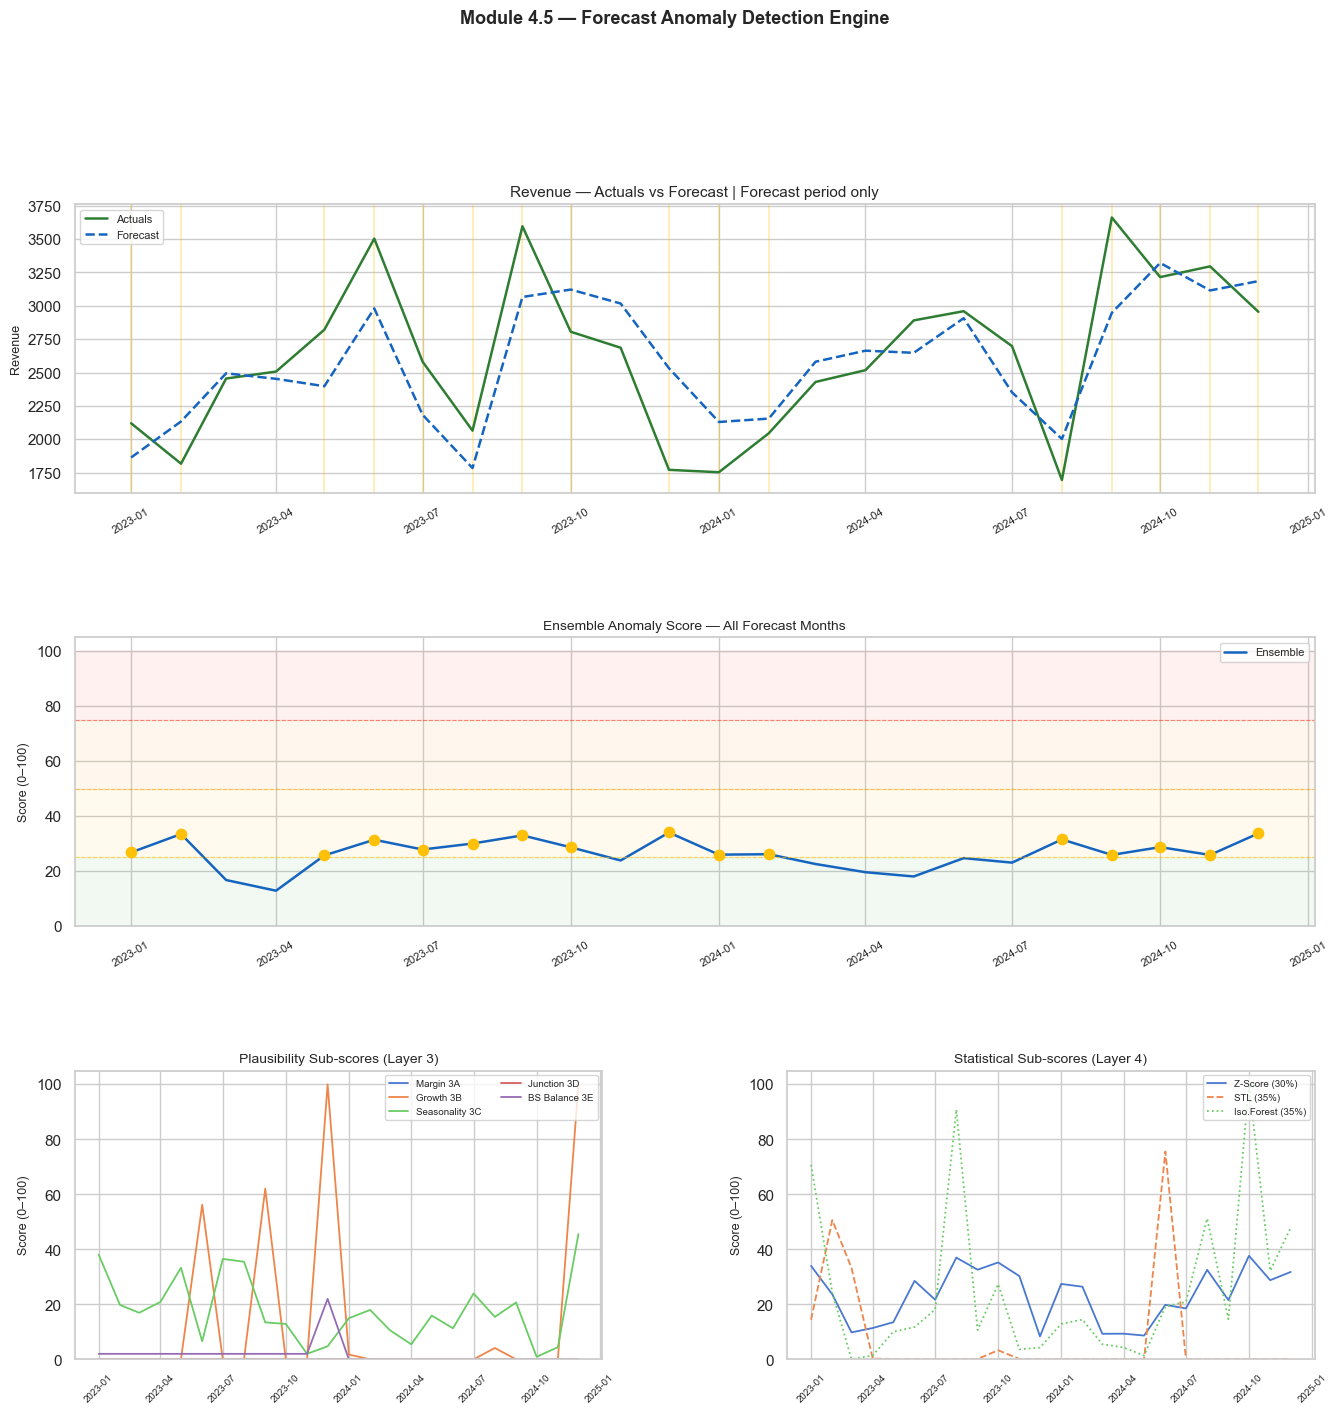

In [12]:
fig = plt.figure(figsize=(16, 15))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.50, wspace=0.35)
sev_colors = {"NORMAL":"#4CAF50","WATCH":"#FFC107","WARNING":"#FF9800","ALERT":"#F44336"}

# ── Panel 1 (top, full width): Revenue actuals vs forecast ────────────────────
ax1 = fig.add_subplot(gs[0, :])
rev_f_col = plf_lower.get("revenue")
rev_a_col = plm_lower.get("revenue")

# Show actuals only for the same months covered by the forecast.
forecast_datekeys_plot = set(df_plf["datekey"].dropna()) if not df_plf.empty else set()
df_plm_plot = df_plm[df_plm["datekey"].isin(forecast_datekeys_plot)].copy() if not df_plm.empty else pd.DataFrame()
df_plf_plot = df_plf.copy()

if rev_a_col and not df_plm_plot.empty:
    ax1.plot(
        df_plm_plot.sort_values("date")["date"],
        df_plm_plot.sort_values("date")[rev_a_col],
        color="#2E7D32",
        linewidth=1.8,
        label="Actuals",
        zorder=3
    )

if rev_f_col and not df_plf_plot.empty:
    ax1.plot(
        df_plf_plot.sort_values("date")["date"],
        df_plf_plot.sort_values("date")[rev_f_col],
        color="#1565C0",
        linewidth=1.8,
        linestyle="--",
        label="Forecast",
        zorder=3
    )

    if fcast_only_datekeys:
        fc_dates = df_plf_plot[df_plf_plot["datekey"].isin(fcast_only_datekeys)]["date"].dropna()
        if not fc_dates.empty:
            ax1.axvspan(fc_dates.min(), fc_dates.max(), alpha=0.07, color="#1565C0")

for _, row in df_ensemble[df_ensemble["severity"] != "NORMAL"].iterrows():
    if pd.notna(row["date"]):
        ax1.axvline(
            row["date"],
            color=sev_colors[row["severity"]],
            alpha=0.35,
            linewidth=1.1
        )

ax1.set_title("Revenue — Actuals vs Forecast | Forecast period only", fontsize=11)
ax1.set_ylabel("Revenue", fontsize=9)
ax1.legend(loc="upper left", fontsize=8)
ax1.tick_params(axis="x", rotation=30, labelsize=8)

# ── Panel 2 (mid, full width): Ensemble score timeline ───────────────────────
ax2 = fig.add_subplot(gs[1, :])
for lo, hi, c in [(0,25,"#4CAF50"),(25,50,"#FFC107"),(50,75,"#FF9800"),(75,100,"#F44336")]:
    ax2.axhspan(lo, hi, alpha=0.07, color=c)

df_es = df_ensemble.sort_values("date")
ax2.plot(df_es["date"], df_es["ensemble_score"], color="#1565C0", linewidth=1.8, label="Ensemble")

for _, row in df_es[df_es["severity"] != "NORMAL"].iterrows():
    if pd.notna(row["date"]):
        ax2.scatter(
            row["date"],
            row["ensemble_score"],
            color=sev_colors[row["severity"]],
            s=55,
            zorder=5
        )

for thresh, col in [(25,"#FFC107"),(50,"#FF9800"),(75,"#F44336")]:
    ax2.axhline(thresh, color=col, linestyle="--", linewidth=0.8, alpha=0.6)

ax2.set_title("Ensemble Anomaly Score — All Forecast Months", fontsize=10)
ax2.set_ylabel("Score (0–100)", fontsize=9)
ax2.set_ylim(0, 105)
ax2.legend(loc="upper right", fontsize=8)
ax2.tick_params(axis="x", rotation=30, labelsize=8)

# ── Panel 3 (bottom-left): Plausibility sub-scores ───────────────────────────
ax3 = fig.add_subplot(gs[2, 0])
plaus_plot = [
    ("margin_score",      "Margin 3A",      "#E53935"),
    ("growth_score",      "Growth 3B",      "#FB8C00"),
    ("seasonality_score", "Seasonality 3C", "#8E24AA"),
    ("junction_score",    "Junction 3D",    "#00897B"),
    ("bs_score",          "BS Balance 3E",  "#1E88E5"),
]

df_ps = df_ensemble.sort_values("date")
for col, lbl, color in plaus_plot:
    if col in df_ps.columns:
        ax3.plot(df_ps["date"], df_ps[col], label=lbl, linewidth=1.3)

ax3.set_title("Plausibility Sub-scores (Layer 3)", fontsize=10)
ax3.set_ylabel("Score (0–100)", fontsize=9)
ax3.set_ylim(0, 105)
ax3.legend(loc="upper right", fontsize=7, ncol=2)
ax3.tick_params(axis="x", rotation=45, labelsize=7)

# ── Panel 4 (bottom-right): Statistical sub-scores ───────────────────────────
ax4 = fig.add_subplot(gs[2, 1])

for col, lbl, ls in [
    ("z_score",   "Z-Score (30%)",    "-"),
    ("stl_score", "STL (35%)",        "--"),
    ("iso_score", "Iso.Forest (35%)", ":"),
]:
    if col in df_es.columns:
        ax4.plot(df_es["date"], df_es[col], label=lbl, linewidth=1.3, linestyle=ls)

ax4.set_title("Statistical Sub-scores (Layer 4)", fontsize=10)
ax4.set_ylabel("Score (0–100)", fontsize=9)
ax4.set_ylim(0, 105)
ax4.legend(loc="upper right", fontsize=7)
ax4.tick_params(axis="x", rotation=45, labelsize=7)

plt.suptitle("Module 4.5 — Forecast Anomaly Detection Engine", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


### Forecast Anomaly Detection - Full Summary

This final summary consolidates the anomaly detection results.  
It shows the data coverage, layer-by-layer findings, the final severity distribution from the ensemble model, and the top forecast months ranked by ensemble score.

In [13]:
print("=" * 90)
print("MODULE 4.5 — FORECAST ANOMALY DETECTION — FULL SUMMARY")
print("=" * 90)

def _date_range(df):
    if df.empty or "date" not in df.columns: return "n/a"
    return f"{df['date'].min().strftime('%Y-%m')} -> {df['date'].max().strftime('%Y-%m')}"

print(f"\nData range:")
print(f"  Actuals  : {_date_range(df_plm)}")
print(f"  Forecast : {_date_range(df_plf)}")
print(f"  Overlap months    : {len(overlap_datekeys)}")
print(f"  Forecast-only     : {len(fcast_only_datekeys)}")

print(f"\nLayer results:")
print(f"  Layer 1A — Quality gate     : {(df_quality['status']=='PASS').sum()}/{len(df_quality)} PASS")
if not df_cv_accuracy.empty:
    print(f"  Layer 2  — Accuracy         : MAPE avg={df_cv_accuracy['MAPE_%'].mean():.1f}%  Bias={df_cv_accuracy['Bias_%'].mean():.1f}%")
else:
    print(f"  Layer 2  — Accuracy         : skipped (no overlap months)")
print(f"  Layer 3A — Margin           : {(df_plf_mg['margin_score'] > 25).sum()} months flagged")
print(f"  Layer 3B — Growth           : {(df_plf_mg['growth_score'] > 25).sum()} months flagged")
print(f"  Layer 3C — Seasonality      : {(df_plf_mg['seasonality_score'] > 25).sum()} months flagged")
print(f"  Layer 3D — Junction         : score = {df_plf_mg['junction_score'].max():.1f}")
print(f"  Layer 3E — BS Balance       : {(df_plf_mg['bs_score'] > 25).sum()} months flagged")
print(f"  Layer 4  — Statistical      : {(df_stat['statistical_score'] > 50).sum()} months flagged")

print(f"\nEnsemble (Layer 5):")
for sev in ["ALERT","WARNING","WATCH","NORMAL"]:
    count = (df_ensemble["severity"] == sev).sum()
    pct   = count / len(df_ensemble) * 100 if len(df_ensemble) else 0
    print(f"  {sev:8s}: {count:4d} ({pct:.1f}%)")

MODULE 4.5 — FORECAST ANOMALY DETECTION — FULL SUMMARY

Data range:
  Actuals  : 2010-01 -> 2024-12
  Forecast : 2023-01 -> 2024-12
  Overlap months    : 24
  Forecast-only     : 0

Layer results:
  Layer 1A — Quality gate     : 12/12 PASS
  Layer 2  — Accuracy         : MAPE avg=186.1%  Bias=2.2%
  Layer 3A — Margin           : 0 months flagged
  Layer 3B — Growth           : 4 months flagged
  Layer 3C — Seasonality      : 5 months flagged
  Layer 3D — Junction         : score = 0.0
  Layer 3E — BS Balance       : 0 months flagged
  Layer 4  — Statistical      : 0 months flagged

Ensemble (Layer 5):
  ALERT   :    0 (0.0%)
  WATCH   :   16 (66.7%)
  NORMAL  :    8 (33.3%)


In [14]:
print("=" * 90)
print("TOP FORECAST MONTHS BY ENSEMBLE SCORE")
print("=" * 90)

detail_cols = [c for c in ["datekey","date","ensemble_score","severity","period_type",
               "accuracy_score","plausibility_score","margin_score","growth_score",
               "seasonality_score","junction_score","bs_score","statistical_score"]
               if c in df_ensemble.columns]
print(df_ensemble.nlargest(10, "ensemble_score")[detail_cols].to_string(index=False))


TOP FORECAST MONTHS BY ENSEMBLE SCORE
 datekey       date  ensemble_score severity period_type  accuracy_score  plausibility_score  margin_score  growth_score  seasonality_score  junction_score  bs_score  statistical_score
  202312 2023-12-01           34.08    WATCH     overlap          100.00               28.15          0.00        100.00               4.74            0.00     22.00               4.05
  202412 2024-12-01           33.76    WATCH     overlap           45.95               34.11          0.00        100.00              45.53            0.00      0.00              26.35
  202302 2023-02-01           33.52    WATCH     overlap          100.00                4.16          0.00          0.00              19.78            0.00      2.00              33.28
  202309 2023-09-01           33.03    WATCH     overlap          100.00               18.41          0.00         62.07              13.44            0.00      2.00              13.56
  202408 2024-08-01           31.56  